In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

# Reading DataFrame and merging

In [2]:
PATH = "../../../data/raw/stad_clinical_patient.parquet"
TARGET_PATH = "../../../data/raw/stad_tmb.parquet"

In [3]:
x = pd.read_csv("/home/youssef_mohammad/projects/DSAI_305_XAI_PROJECT/DSAI_305_XAI/data/clinical.csv")
x.head(2)

,PATIENT_ID,AGE,AJCC_STAGING_EDITION,BIOPSY_SITE,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_DEATH,DISEASE_TYPE,ETHNICITY,ICD_10,...,PROJECT_STATE,SAMPLE_ID,IS_FFPE,OTHER_SAMPLE_ID,SAMPLE_TYPE,SAMPLE_TYPE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TMB_NONSYNONYMOUS
0,TCGA-3L-AA1B,61.0,7th,Colon,154.0,-22379.0,NaN,Colon Adenocarcinoma,NOT HISPANIC OR LATINO,C18.0,...,released,TCGA-3L-AA1B-01A,NO,22996dd0-8d03-49f2-8395-738c0599339b,Primary Tumor,1,COAD,Colon Adenocarcinoma,Colon Adenocarcinoma,3.333333
1,TCGA-4N-A93T,67.0,7th,Colon,8.0,-24523.0,NaN,Colon Adenocarcinoma,NOT HISPANIC OR LATINO,C18.2,...,released,TCGA-4N-A93T-01A,NO,7904523e-e859-47b9-8ba0-c1a1363afa0c,Primary Tumor,1,COAD,Colon Adenocarcinoma,Colon Adenocarcinoma,2.366667


In [4]:
y = pd.read_parquet(TARGET_PATH)
y.head(2)

,PATIENT_ID,SAMPLE_ID,TMB_NONSYNONYMOUS
0,TCGA-3M-AB46,TCGA-3M-AB46-01,5.600000
1,TCGA-3M-AB47,TCGA-3M-AB47-01,3.566667


In [4]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PATIENT_ID            463 non-null    str    
 1   AGE                   459 non-null    float64
 2   AJCC_STAGING_EDITION  406 non-null    str    
 3   BIOPSY_SITE           460 non-null    str    
 4   DAYS_LAST_FOLLOWUP    414 non-null    float64
 5   DAYS_TO_BIRTH         459 non-null    float64
 6   DAYS_TO_DEATH         102 non-null    float64
 7   DISEASE_TYPE          456 non-null    str    
 8   ETHNICITY             277 non-null    str    
 9   ICD_10                461 non-null    str    
 10  MORPHOLOGY            461 non-null    str    
 11  OTHER_PATIENT_ID      461 non-null    str    
 12  PATH_M_STAGE          454 non-null    str    
 13  PATH_N_STAGE          461 non-null    str    
 14  PATH_STAGE            450 non-null    str    
 15  PATH_T_STAGE          461 non-null

In [5]:
(x.isna().sum() / x.shape[0] * 100).sort_values(ascending=False)

DAYS_TO_DEATH           77.969762
DFS_STATUS              62.634989
DFS_MONTHS              62.634989
ETHNICITY               40.172786
RACE                    38.012959
AJCC_STAGING_EDITION    12.311015
DAYS_LAST_FOLLOWUP      10.583153
TMB_NONSYNONYMOUS        7.343413
PATH_STAGE               2.807775
PATH_M_STAGE             1.943844
DISEASE_TYPE             1.511879
PRIMARY_DIAGNOSIS        1.511879
PRIOR_MALIGNANCY         0.863931
AGE                      0.863931
DAYS_TO_BIRTH            0.863931
BIOPSY_SITE              0.647948
PRIMARY_SITE_PATIENT     0.647948
OS_MONTHS                0.647948
YEAR_OF_DIAGNOSIS        0.431965
OTHER_PATIENT_ID         0.431965
PATH_T_STAGE             0.431965
PATH_N_STAGE             0.431965
MORPHOLOGY               0.431965
ICD_10                   0.431965
OS_STATUS                0.431965
VITAL_STATUS             0.431965
SEX                      0.431965
PRIOR_TREATMENT          0.431965
PATIENT_ID               0.000000
PROJECT_ID    

In [7]:
y.isna().sum()

PATIENT_ID           0
SAMPLE_ID            0
TMB_NONSYNONYMOUS    4
dtype: int64

In [ ]:
print(y.shape[0])
y.dropna(inplace=True)
y.drop(inplace=True, columns=["SAMPLE_ID"])
y.shape[0]

In [9]:
df = pd.merge(x, y, on="PATIENT_ID", how="inner")
df.shape[0] - x.shape[0]

-4

In [8]:
df = x

In [10]:
df.rename(columns={"TMB_NONSYNONYMOUS": "TMB"}, inplace=True)

# Identify Features

Final Findings:
{'feature': ['skewness', 'outliers']}
* DAYS-TO-INITIAL_PATHOLOGIC_DIAGNOSIS is the only centered skewed feature.
* AGE is the only -ve skewed


In [11]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()
print("Numeric Features:", numeric_features, "\n----------")
print("Categorical Features:", categorical_features)

Numeric Features: ['AGE', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_DEATH', 'YEAR_OF_DIAGNOSIS', 'OS_MONTHS', 'DFS_MONTHS', 'SAMPLE_TYPE_ID', 'TMB'] 
----------
Categorical Features: ['PATIENT_ID', 'AJCC_STAGING_EDITION', 'BIOPSY_SITE', 'DISEASE_TYPE', 'ETHNICITY', 'ICD_10', 'MORPHOLOGY', 'OTHER_PATIENT_ID', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_STAGE', 'PATH_T_STAGE', 'PRIMARY_DIAGNOSIS', 'PRIMARY_SITE_PATIENT', 'PRIOR_MALIGNANCY', 'PRIOR_TREATMENT', 'RACE', 'SEX', 'VITAL_STATUS', 'OS_STATUS', 'DFS_STATUS', 'PROJECT_ID', 'PROJECT_NAME', 'PROJECT_STATE', 'SAMPLE_ID', 'IS_FFPE', 'OTHER_SAMPLE_ID', 'SAMPLE_TYPE', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED']


In [16]:
ordinal_features = [
    # "AJCC_PATHOLOGIC_TUMOR_STAGE",
    "PATH_T_STAGE",
    "PATH_N_STAGE",
    "PATH_M_STAGE",
    "AJCC_STAGING_EDITION",
    # "PERSON_NEOPLASM_CANCER_STATUS",
]
categorical_features = [f for f in categorical_features if f not in ordinal_features]

In [17]:
df[ordinal_features] = df[ordinal_features].astype("object")

## Check Skewness

### numerically

In [18]:
def classify_skewness(df, features, dictionary=None, threshold=0.5):
    """
    Classify skewness of given features in a DataFrame.
    Parameters:
        df (pd.DataFrame): input dataframe
        features (list): list of column names
        threshold (float): cutoff for considering skewness (default=0.5)
    Returns:
        dict: {feature: {'skewness': value, 'category': label}}
    """
    if not dictionary:
        dictionary = {feat: dict() for feat in features}
    for col in features:
        skew_val = df[col].skew()
        if skew_val > threshold:
            category = "skewed_positive"
        elif skew_val < -threshold:
            category = "skewed_negative"
        else:
            category = "centered"
        dictionary[col]["skewness"] = {"value": skew_val, "category": category}
    return dictionary

In [19]:
numeric_features_stats = classify_skewness(df, numeric_features)
numeric_features_stats

{'AGE': {'skewness': {'value': np.float64(-0.4556722557691789),
   'category': 'centered'}},
 'DAYS_LAST_FOLLOWUP': {'skewness': {'value': np.float64(3.1381013840954144),
   'category': 'skewed_positive'}},
 'DAYS_TO_BIRTH': {'skewness': {'value': np.float64(0.4500698924703077),
   'category': 'centered'}},
 'DAYS_TO_DEATH': {'skewness': {'value': np.float64(1.5916242829311569),
   'category': 'skewed_positive'}},
 'YEAR_OF_DIAGNOSIS': {'skewness': {'value': np.float64(-1.0762327420233047),
   'category': 'skewed_negative'}},
 'OS_MONTHS': {'skewness': {'value': np.float64(2.04521347891686),
   'category': 'skewed_positive'}},
 'DFS_MONTHS': {'skewness': {'value': np.float64(2.270755186239948),
   'category': 'skewed_positive'}},
 'SAMPLE_TYPE_ID': {'skewness': {'value': np.float64(20.44426961741761),
   'category': 'skewed_positive'}},
 'TMB': {'skewness': {'value': np.float64(6.313405692191556),
   'category': 'skewed_positive'}}}

### visually

FileNotFoundError: [Errno 2] No such file or directory: '../../../assets/EDA-charts/stad-clinical-numeric-pairplot.png'

<Figure size 3000x3000 with 0 Axes>

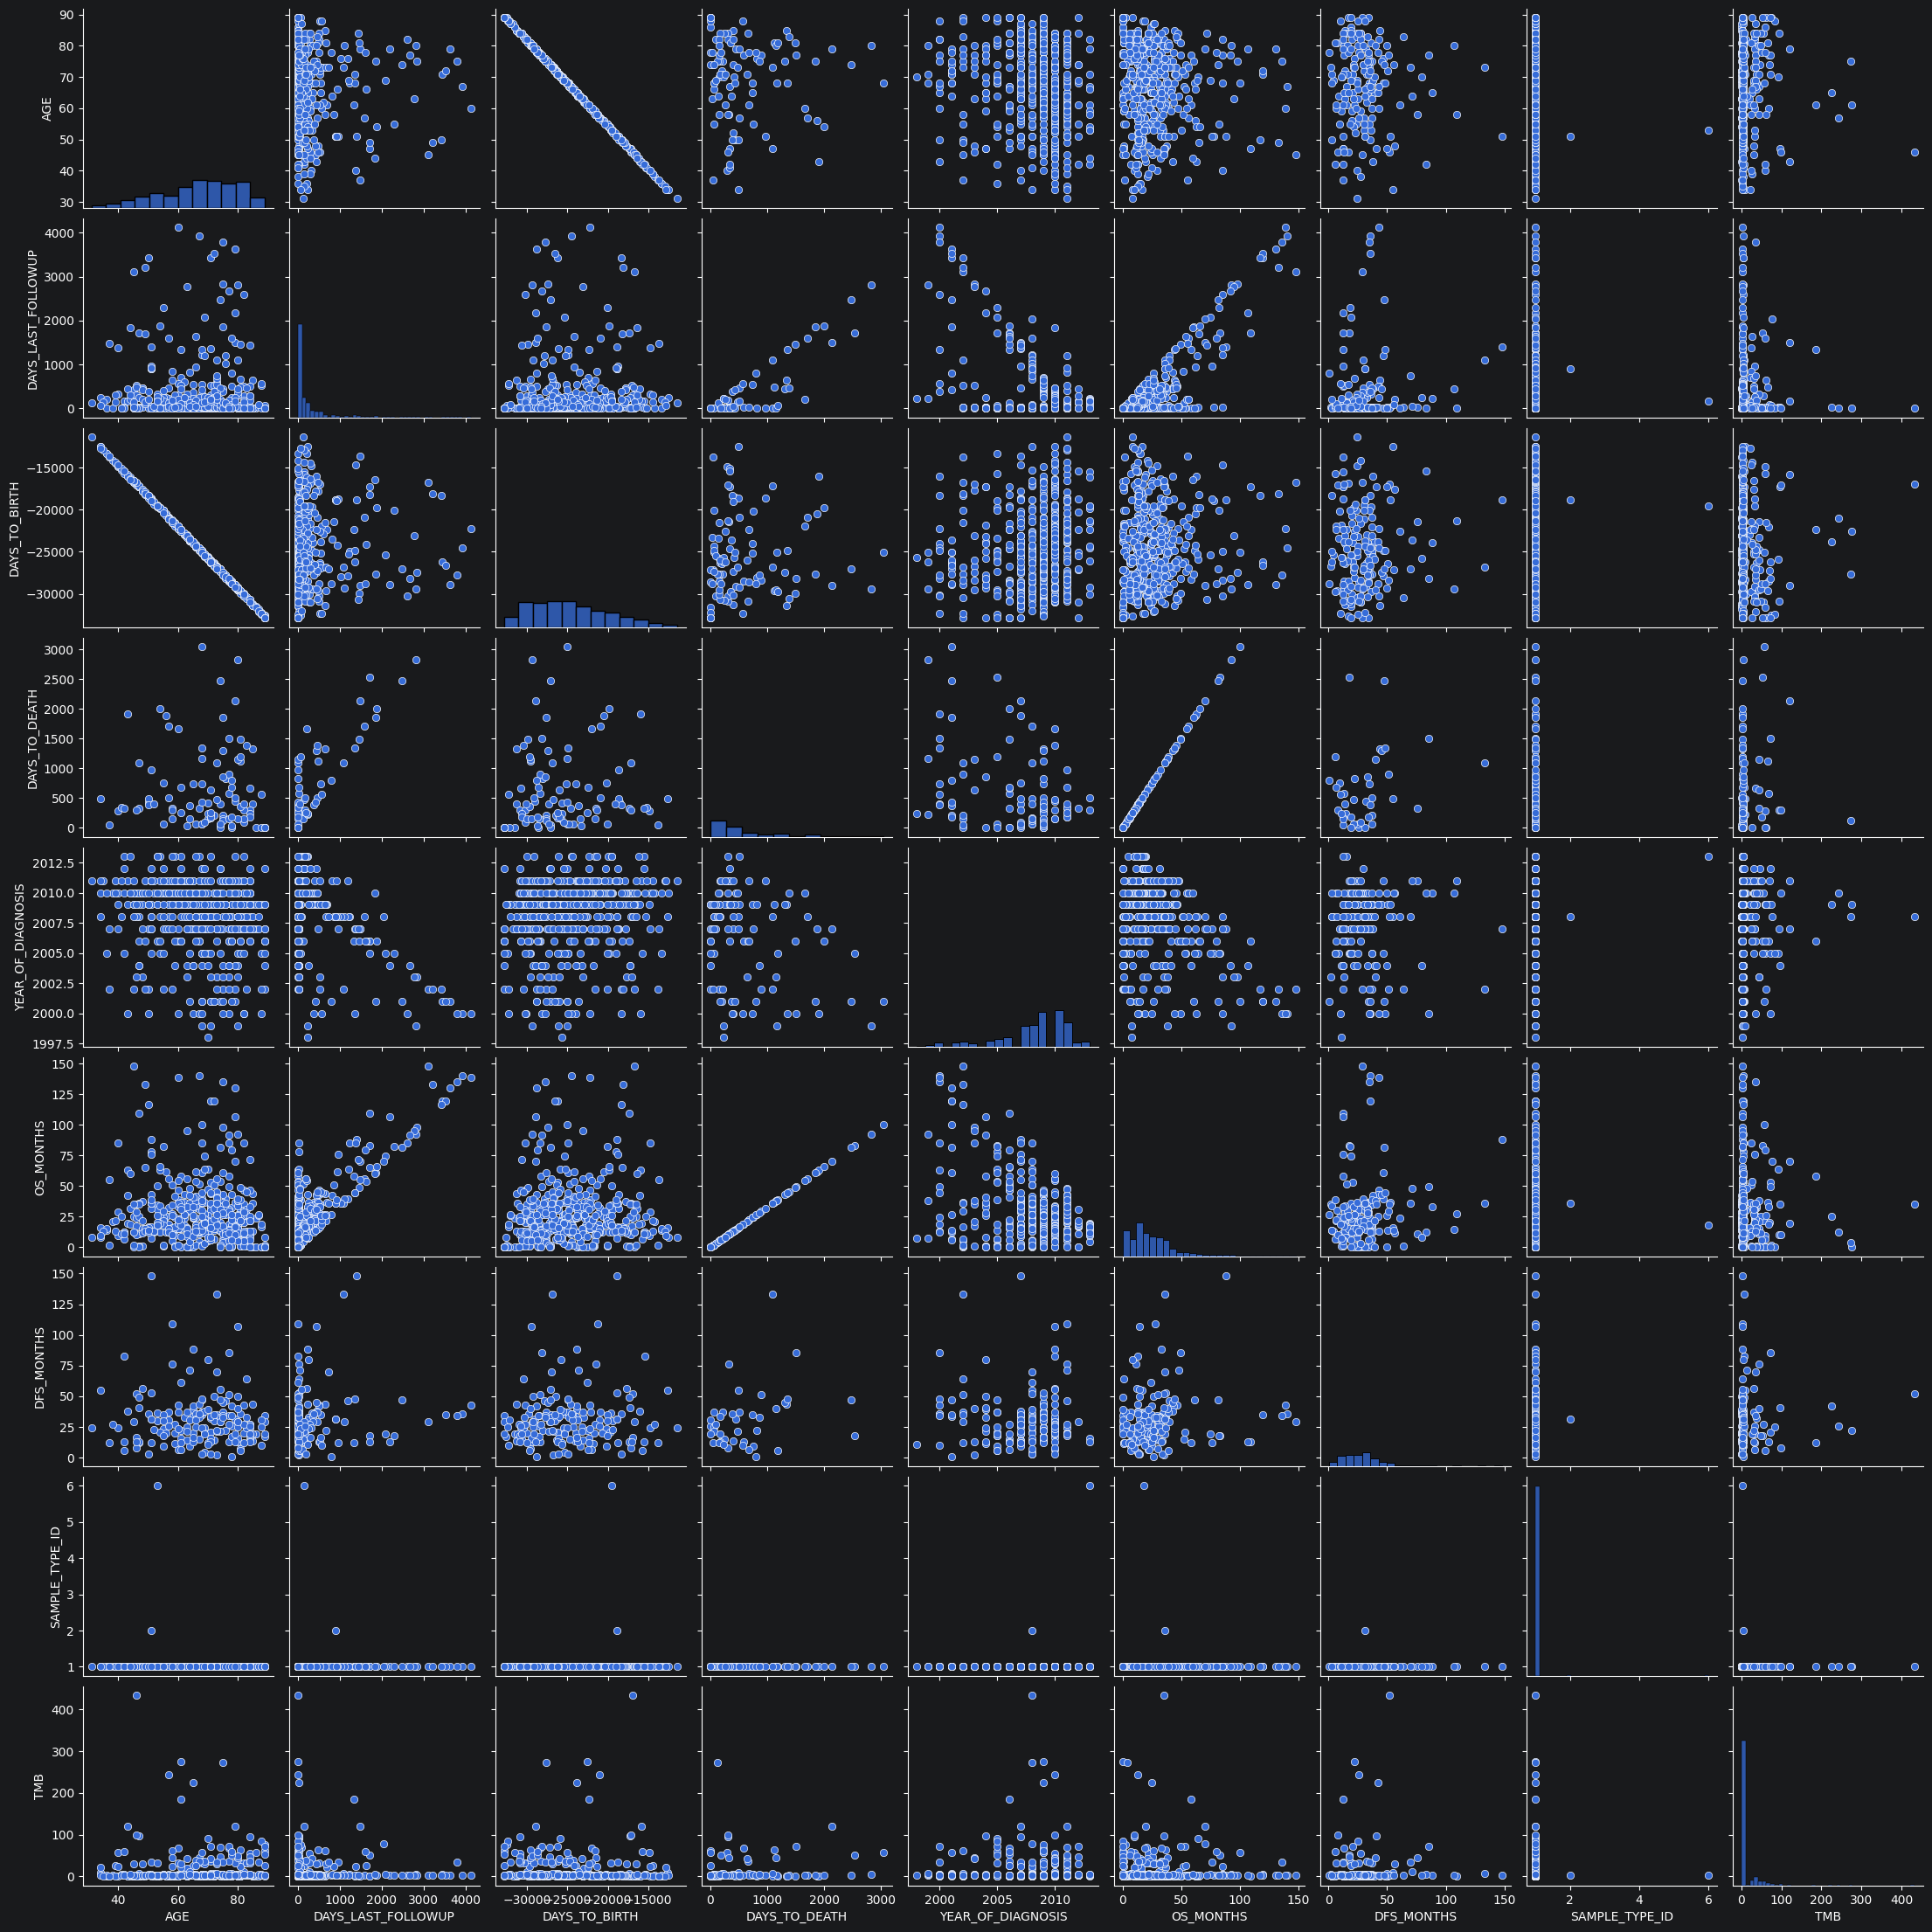

In [20]:
plt.figure(figsize=(30, 30))
sns.pairplot(df[numeric_features], diag_kind="hist")
plt.savefig(
    "../../../assets/EDA-charts/stad-clinical-numeric-pairplot.png",
    dpi=300,
    bbox_inches="tight",
)
# plt.show()

## check distribution

## check outliers


In [22]:
def check_outliers(
    df,
    features,
    numeric_features_shape_summary=None,
    z_thresh=3,
    iqr_multiplier=1.5,
    kurt_thresh=3,
):
    """
    For each feature:
        - compute std (Z-score method)
        - compute IQR bounds
        - compute kurtosis (distribution-level)
        - detect outliers using both Z-score and IQR
        - if both methods agree → automatic decision
        - else → flag for manual review

    Parameters:
        df (pd.DataFrame)
        numeric_features_shape_summary (dict): {feature: [flags...]} (optional)
        z_thresh (float): Z-score threshold (default=3)
        iqr_multiplier (float): IQR multiplier (default=1.5)
        kurt_thresh (float): threshold for high kurtosis (default=3)

    Returns:
        updated_summary (dict): feature → contains_outliers (True/False)
        manual_review (dict): feature → detailed metrics + disagreement info
    """
    if numeric_features_shape_summary is None:
        numeric_features_shape_summary = {feat: dict() for feat in features}

    for col in df.select_dtypes(include=np.number).columns:
        series = df[col].dropna()

        # --- Z-score method ---
        mean = series.mean()
        std = series.std()
        z_scores = (series - mean) / std
        z_outliers = np.abs(z_scores) > z_thresh

        # --- IQR method ---
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR

        iqr_outliers = (series < lower_bound) | (series > upper_bound)

        # --- Kurtosis ---
        kurt = series.kurt()

        # --- Agreement logic ---
        z_flag = z_outliers.any()
        iqr_flag = iqr_outliers.any()
        kurt_flag = kurt > kurt_thresh  # heavy tails

        numeric_features_shape_summary[col]["outliers"] = {
            "flag": (z_flag if z_flag == iqr_flag else "manual"),
            "z_flag": z_flag,
            "iqr_flag": iqr_flag,
            "kurt_flag": kurt_flag,
            "z_count": int(z_outliers.sum()),
            "iqr_count": int(iqr_outliers.sum()),
            "kurtosis": kurt,
        }

    return numeric_features_shape_summary

In [23]:
numeric_features_stats = check_outliers(df, numeric_features, numeric_features_stats)
numeric_features_stats

{'AGE': {'skewness': {'value': np.float64(-0.4556722557691789),
   'category': 'centered'},
  'outliers': {'flag': np.False_,
   'z_flag': np.False_,
   'iqr_flag': np.False_,
   'kurt_flag': np.False_,
   'z_count': 0,
   'iqr_count': 0,
   'kurtosis': np.float64(-0.5124785371133473)}},
 'DAYS_LAST_FOLLOWUP': {'skewness': {'value': np.float64(3.1381013840954144),
   'category': 'skewed_positive'},
  'outliers': {'flag': np.True_,
   'z_flag': np.True_,
   'iqr_flag': np.True_,
   'kurt_flag': np.True_,
   'z_count': 15,
   'iqr_count': 51,
   'kurtosis': np.float64(10.325684394373521)}},
 'DAYS_TO_BIRTH': {'skewness': {'value': np.float64(0.4500698924703077),
   'category': 'centered'},
  'outliers': {'flag': np.False_,
   'z_flag': np.False_,
   'iqr_flag': np.False_,
   'kurt_flag': np.False_,
   'z_count': 0,
   'iqr_count': 0,
   'kurtosis': np.float64(-0.5150403270801136)}},
 'DAYS_TO_DEATH': {'skewness': {'value': np.float64(1.5916242829311569),
   'category': 'skewed_positive'}

## Categorical

In [24]:
def plot_categorical_pies(
    df, categorical_features, max_cols=3, figsize=(15, 10), output_dir=None
):
    """
    Plots pie charts for multiple categorical features in a subplot grid.

    Parameters:
        df (pd.DataFrame): input dataframe
        categorical_features (list): list of categorical column names
        max_cols (int): max number of columns in grid
        figsize (tuple): figure size
    """

    n_features = len(categorical_features)
    n_cols = min(max_cols, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    # flatten axes for easy iteration
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, col in enumerate(categorical_features):
        value_counts = df[col].value_counts(dropna=False)

        axes[i].pie(
            value_counts.values,
            labels=value_counts.index.astype(str),
            autopct="%1.1f%%",
            startangle=90,
        )
        axes[i].set_title(col)

    # hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    if output_dir:
        plt.savefig(output_dir, dpi=300, bbox_inches="tight")

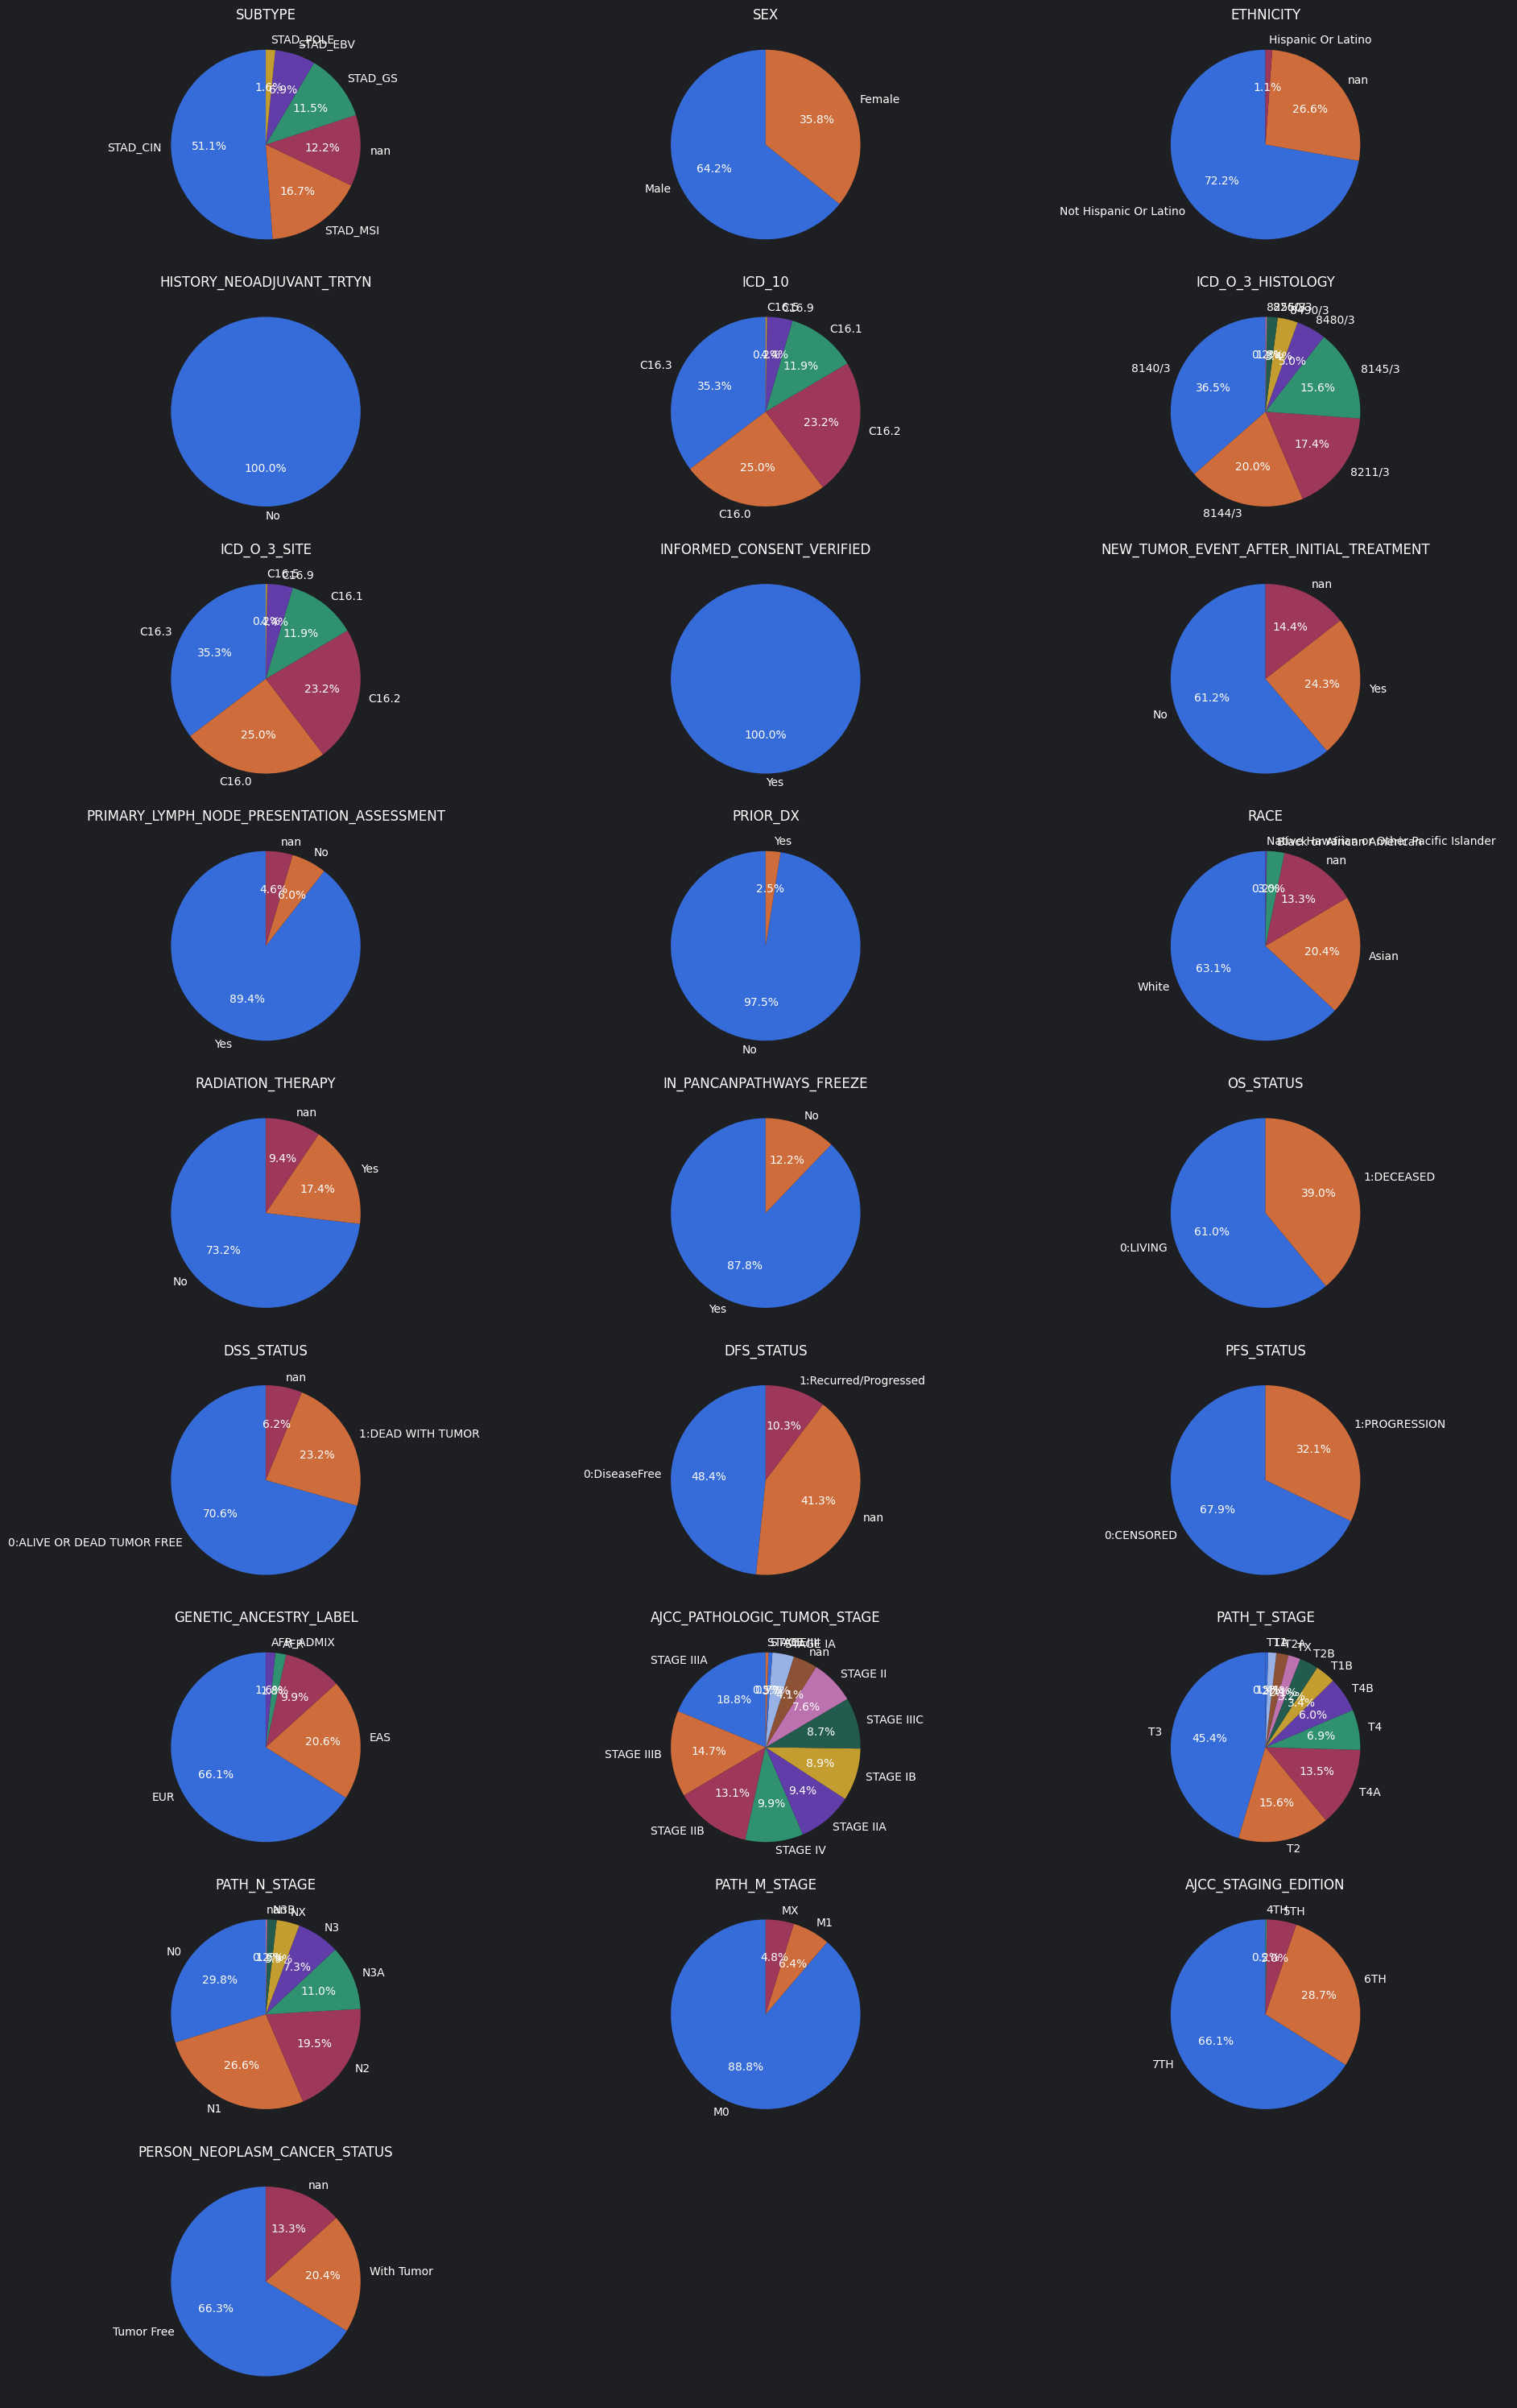

In [21]:
plot_categorical_pies(
    df,
    categorical_features[1:] + ordinal_features,
    max_cols=3,
    figsize=(20, 30),
    output_dir="../../../assets/EDA-charts/stad-clinical-categorical-pies.png",
)

# Get final stats dictionaries

## numerical features

In [25]:
def convert_stats_dictionary_to_dataframe(stats_dict):
    """
    Convert the nested stats dictionary into a flat DataFrame for easier analysis.
    Parameters:
        stats_dict (dict): {feature: {metric: {value}}}
    Returns:
        pd.DataFrame: columns = [feature, metric, field, value]
    """
    rows = []

    for feature, metrics in stats_dict.items():
        for metric, fields in metrics.items():
            for field, value in fields.items():
                rows.append((metric, field, feature, value))
    result = pd.DataFrame(rows, columns=["metric", "field", "feature", "value"])
    return result.pivot(index=["metric", "field"], columns="feature", values="value")

In [26]:
numeric_features_stats = convert_stats_dictionary_to_dataframe(numeric_features_stats)
numeric_features_stats

feature                  AGE DAYS_LAST_FOLLOWUP DAYS_TO_BIRTH  \
metric   field                                                  
outliers flag          False               True         False   
         iqr_count         0                 51             0   
         iqr_flag      False               True         False   
         kurt_flag     False               True         False   
         kurtosis  -0.512479          10.325684      -0.51504   
         z_count           0                 15             0   
         z_flag        False               True         False   
skewness category   centered    skewed_positive      centered   
         value     -0.455672           3.138101       0.45007   

feature               DAYS_TO_DEATH       DFS_MONTHS        OS_MONTHS  \
metric   field                                                          
outliers flag                  True             True             True   
         iqr_count                7               11               31   
         iqr_flag              True             True             True   
         kurt_flag            False             True             True   
         kurtosis          2.154461         7.657186         5.393009   
         z_count                  2                4               11   
         z_flag                True             True             True   
skewness category   skewed_positive  skewed_positive  skewed_positive   
         value             1.591624         2.270755         2.045213   

feature              SAMPLE_TYPE_ID              TMB YEAR_OF_DIAGNOSIS  
metric   field                                                          
outliers flag                  True             True              True  
         iqr_count                2               79                39  
         iqr_flag              True             True              True  
         kurt_flag             True             True             False  
         kurtosis        428.474282        51.991999          0.788086  
         z_count                  2                6                 1  
         z_flag                True             True              True  
skewness category   skewed_positive  skewed_positive   skewed_negative  
         value             20.44427         6.313406         -1.076233

# central tendency

In [28]:
def add_central_tendency(df, df_profile, feature_list):
    """
    df: original dataframe (for computing values)
    df_profile: your existing (metric, field) x feature matrix
    feature_list: numeric features only
    """

    for feat in feature_list:
        # ------------------------
        # read existing flags
        # ------------------------
        skew_flag = df_profile.loc[("skewness", "category"), feat] != "centered"
        outlier_flag = df_profile.loc[("outliers", "flag"), feat]

        series = df[feat].dropna()

        # ------------------------
        # decision
        # ------------------------
        if (not skew_flag) and (not outlier_flag):
            measure = "mean"
            value = series.mean()
        else:
            measure = "median"
            value = series.median()

        # ------------------------
        # store result
        #
        # ------------------------
        df_profile.at[("central_tendency", "measure"), feat] = measure
        df_profile.at[("central_tendency", "value"), feat] = value

    return df_profile

In [29]:
numeric_features_stats = add_central_tendency(
    df, numeric_features_stats, numeric_features
)
numeric_features_stats

feature                           AGE DAYS_LAST_FOLLOWUP DAYS_TO_BIRTH  \
metric           field                                                   
outliers         flag           False               True         False   
                 iqr_count          0                 51             0   
                 iqr_flag       False               True         False   
                 kurt_flag      False               True         False   
                 kurtosis   -0.512479          10.325684      -0.51504   
                 z_count            0                 15             0   
                 z_flag         False               True         False   
skewness         category    centered    skewed_positive      centered   
                 value      -0.455672           3.138101       0.45007   
central_tendency measure         mean             median          mean   
                 value      66.832244               41.5 -24589.734205   

feature                       DAYS_TO_DEATH       DFS_MONTHS        OS_MONTHS  \
metric           field                                                          
outliers         flag                  True             True             True   
                 iqr_count                7               11               31   
                 iqr_flag              True             True             True   
                 kurt_flag            False             True             True   
                 kurtosis          2.154461         7.657186         5.393009   
                 z_count                  2                4               11   
                 z_flag                True             True             True   
skewness         category   skewed_positive  skewed_positive  skewed_positive   
                 value             1.591624         2.270755         2.045213   
central_tendency measure             median           median           median   
                 value                375.5        27.024361        21.583443   

feature                      SAMPLE_TYPE_ID              TMB YEAR_OF_DIAGNOSIS  
metric           field                                                          
outliers         flag                  True             True              True  
                 iqr_count                2               79                39  
                 iqr_flag              True             True              True  
                 kurt_flag             True             True             False  
                 kurtosis        428.474282        51.991999          0.788086  
                 z_count                  2                6                 1  
                 z_flag                True             True              True  
skewness         category   skewed_positive  skewed_positive   skewed_negative  
                 value             20.44427         6.313406         -1.076233  
central_tendency measure             median           median            median  
                 value                  1.0         3.166667            2009.0

# Multivariate

## Functions

In [30]:
# ----------------------------
# correlation ratio (categorical → numeric)
# ----------------------------
def correlation_ratio(categories, values):
    fcat, _ = pd.factorize(categories)
    cat_means = np.zeros(np.max(fcat) + 1)

    for i in range(len(cat_means)):
        cat_means[i] = values[fcat == i].mean()

    overall_mean = values.mean()

    numerator = 0.0
    denominator = ((values - overall_mean) ** 2).sum()

    for i in range(len(cat_means)):
        numerator += np.sum((values[fcat == i].mean() - overall_mean) ** 2)

    return np.sqrt(numerator / denominator) if denominator != 0 else 0


# ----------------------------
# uncertainty coefficient (categorical ↔ categorical)
# ----------------------------
def uncertainty_coefficient(x, y):
    df = pd.crosstab(x, y)

    joint_prob = df / df.values.sum()
    x_prob = joint_prob.sum(axis=1)
    y_prob = joint_prob.sum(axis=0)

    hx = -np.nansum(x_prob * np.log(x_prob + 1e-12))
    hy = -np.nansum(y_prob * np.log(y_prob + 1e-12))
    hxy = -np.nansum(joint_prob * np.log(joint_prob + 1e-12))

    return (hx + hy - hxy) / hx if hx != 0 else 0

## Engine


In [34]:
def is_numeric(s):
    return pd.api.types.is_numeric_dtype(s)


def multivariate_relationships(df, target, path):
    results = {}

    for col in df.columns:
        if col == target:
            continue

        x = df[target]
        y = df[col]

        # -----------------------
        # NUMERIC vs NUMERIC
        # -----------------------
        if is_numeric(x) and is_numeric(y):
            rho, _ = spearmanr(x, y, nan_policy="omit")

            results[col] = {
                "type": "numeric-numeric",
                "spearman": 100 * float(rho),
            }

        # -----------------------
        # CATEGORICAL vs NUMERIC
        # -----------------------
        elif not is_numeric(x) and is_numeric(y):
            results[col] = {
                "type": "categorical-numeric",
                "correlation_ratio": float(correlation_ratio(x, y)) * 100,
            }

        # -----------------------
        # NUMERIC vs CATEGORICAL
        # -----------------------
        elif is_numeric(x) and not is_numeric(y):
            results[col] = {
                "type": "numeric-categorical",
                "correlation_ratio": float(correlation_ratio(y, x)) * 100,
            }

        # -----------------------
        # CATEGORICAL vs CATEGORICAL
        # -----------------------
        else:
            results[col] = {
                "type": "categorical-categorical",
                "uncertainty_coefficient": float(uncertainty_coefficient(x, y)) * 100,
            }

    corr = pd.DataFrame(results)

    corr.loc[target] = corr.iloc[1:, :].sum().values
    heatmap_df = corr.loc[target].to_frame().T
    heatmap_df = heatmap_df.apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(30, 5))
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".1f",
        cmap="vlag",
        vmin=-100,
        vmax=100,
        cbar=True,
        annot_kws={"size": 12},
    )
    # plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return corr

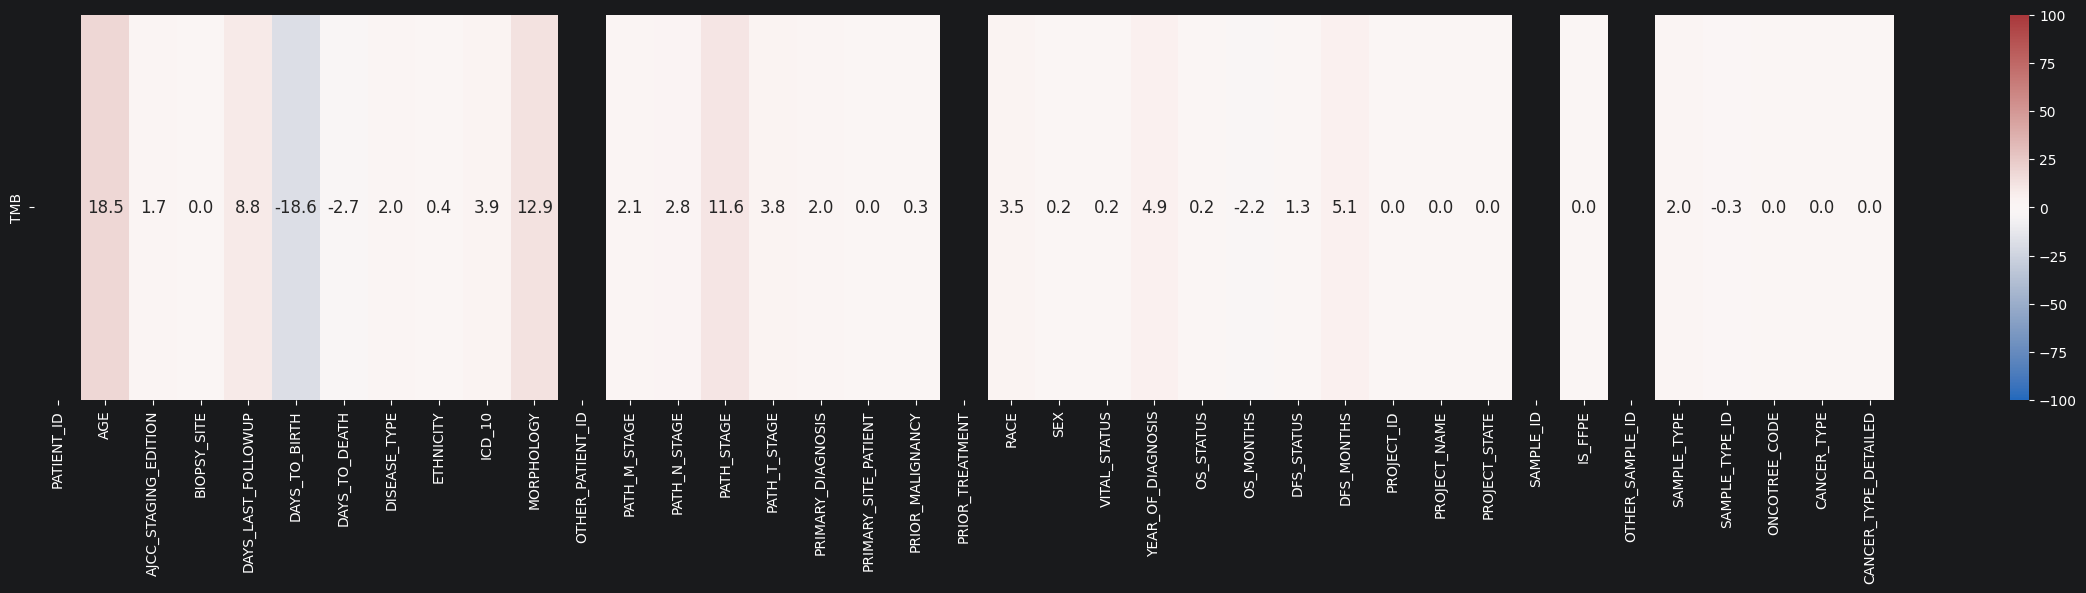

,PATIENT_ID,AGE,AJCC_STAGING_EDITION,BIOPSY_SITE,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_DEATH,DISEASE_TYPE,ETHNICITY,ICD_10,...,PROJECT_NAME,PROJECT_STATE,SAMPLE_ID,IS_FFPE,OTHER_SAMPLE_ID,SAMPLE_TYPE,SAMPLE_TYPE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED
type,numeric-categorical,numeric-numeric,numeric-categorical,numeric-categorical,numeric-numeric,numeric-numeric,numeric-numeric,numeric-categorical,numeric-categorical,numeric-categorical,...,numeric-categorical,numeric-categorical,numeric-categorical,numeric-categorical,numeric-categorical,numeric-categorical,numeric-numeric,numeric-categorical,numeric-categorical,numeric-categorical
correlation_ratio,NaN,NaN,1.728328,0.010762,NaN,NaN,NaN,1.982893,0.446617,3.86002,...,0.0,0.0,NaN,0.0,NaN,2.025739,NaN,0.0,0.0,0.0
spearman,NaN,18.498269,NaN,NaN,8.787297,-18.642321,-2.689502,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.336938,NaN,NaN,NaN
TMB,,18.498269,1.728328,0.010762,8.787297,-18.642321,-2.689502,1.982893,0.446617,3.86002,...,0.0,0.0,,0.0,,2.025739,-0.336938,0.0,0.0,0.0


In [35]:
multivariate_relationships(
    df, "TMB", "../../../assets//EDA-charts/stad-clinical-target-corr-heatmap.png"
)

<Axes: >

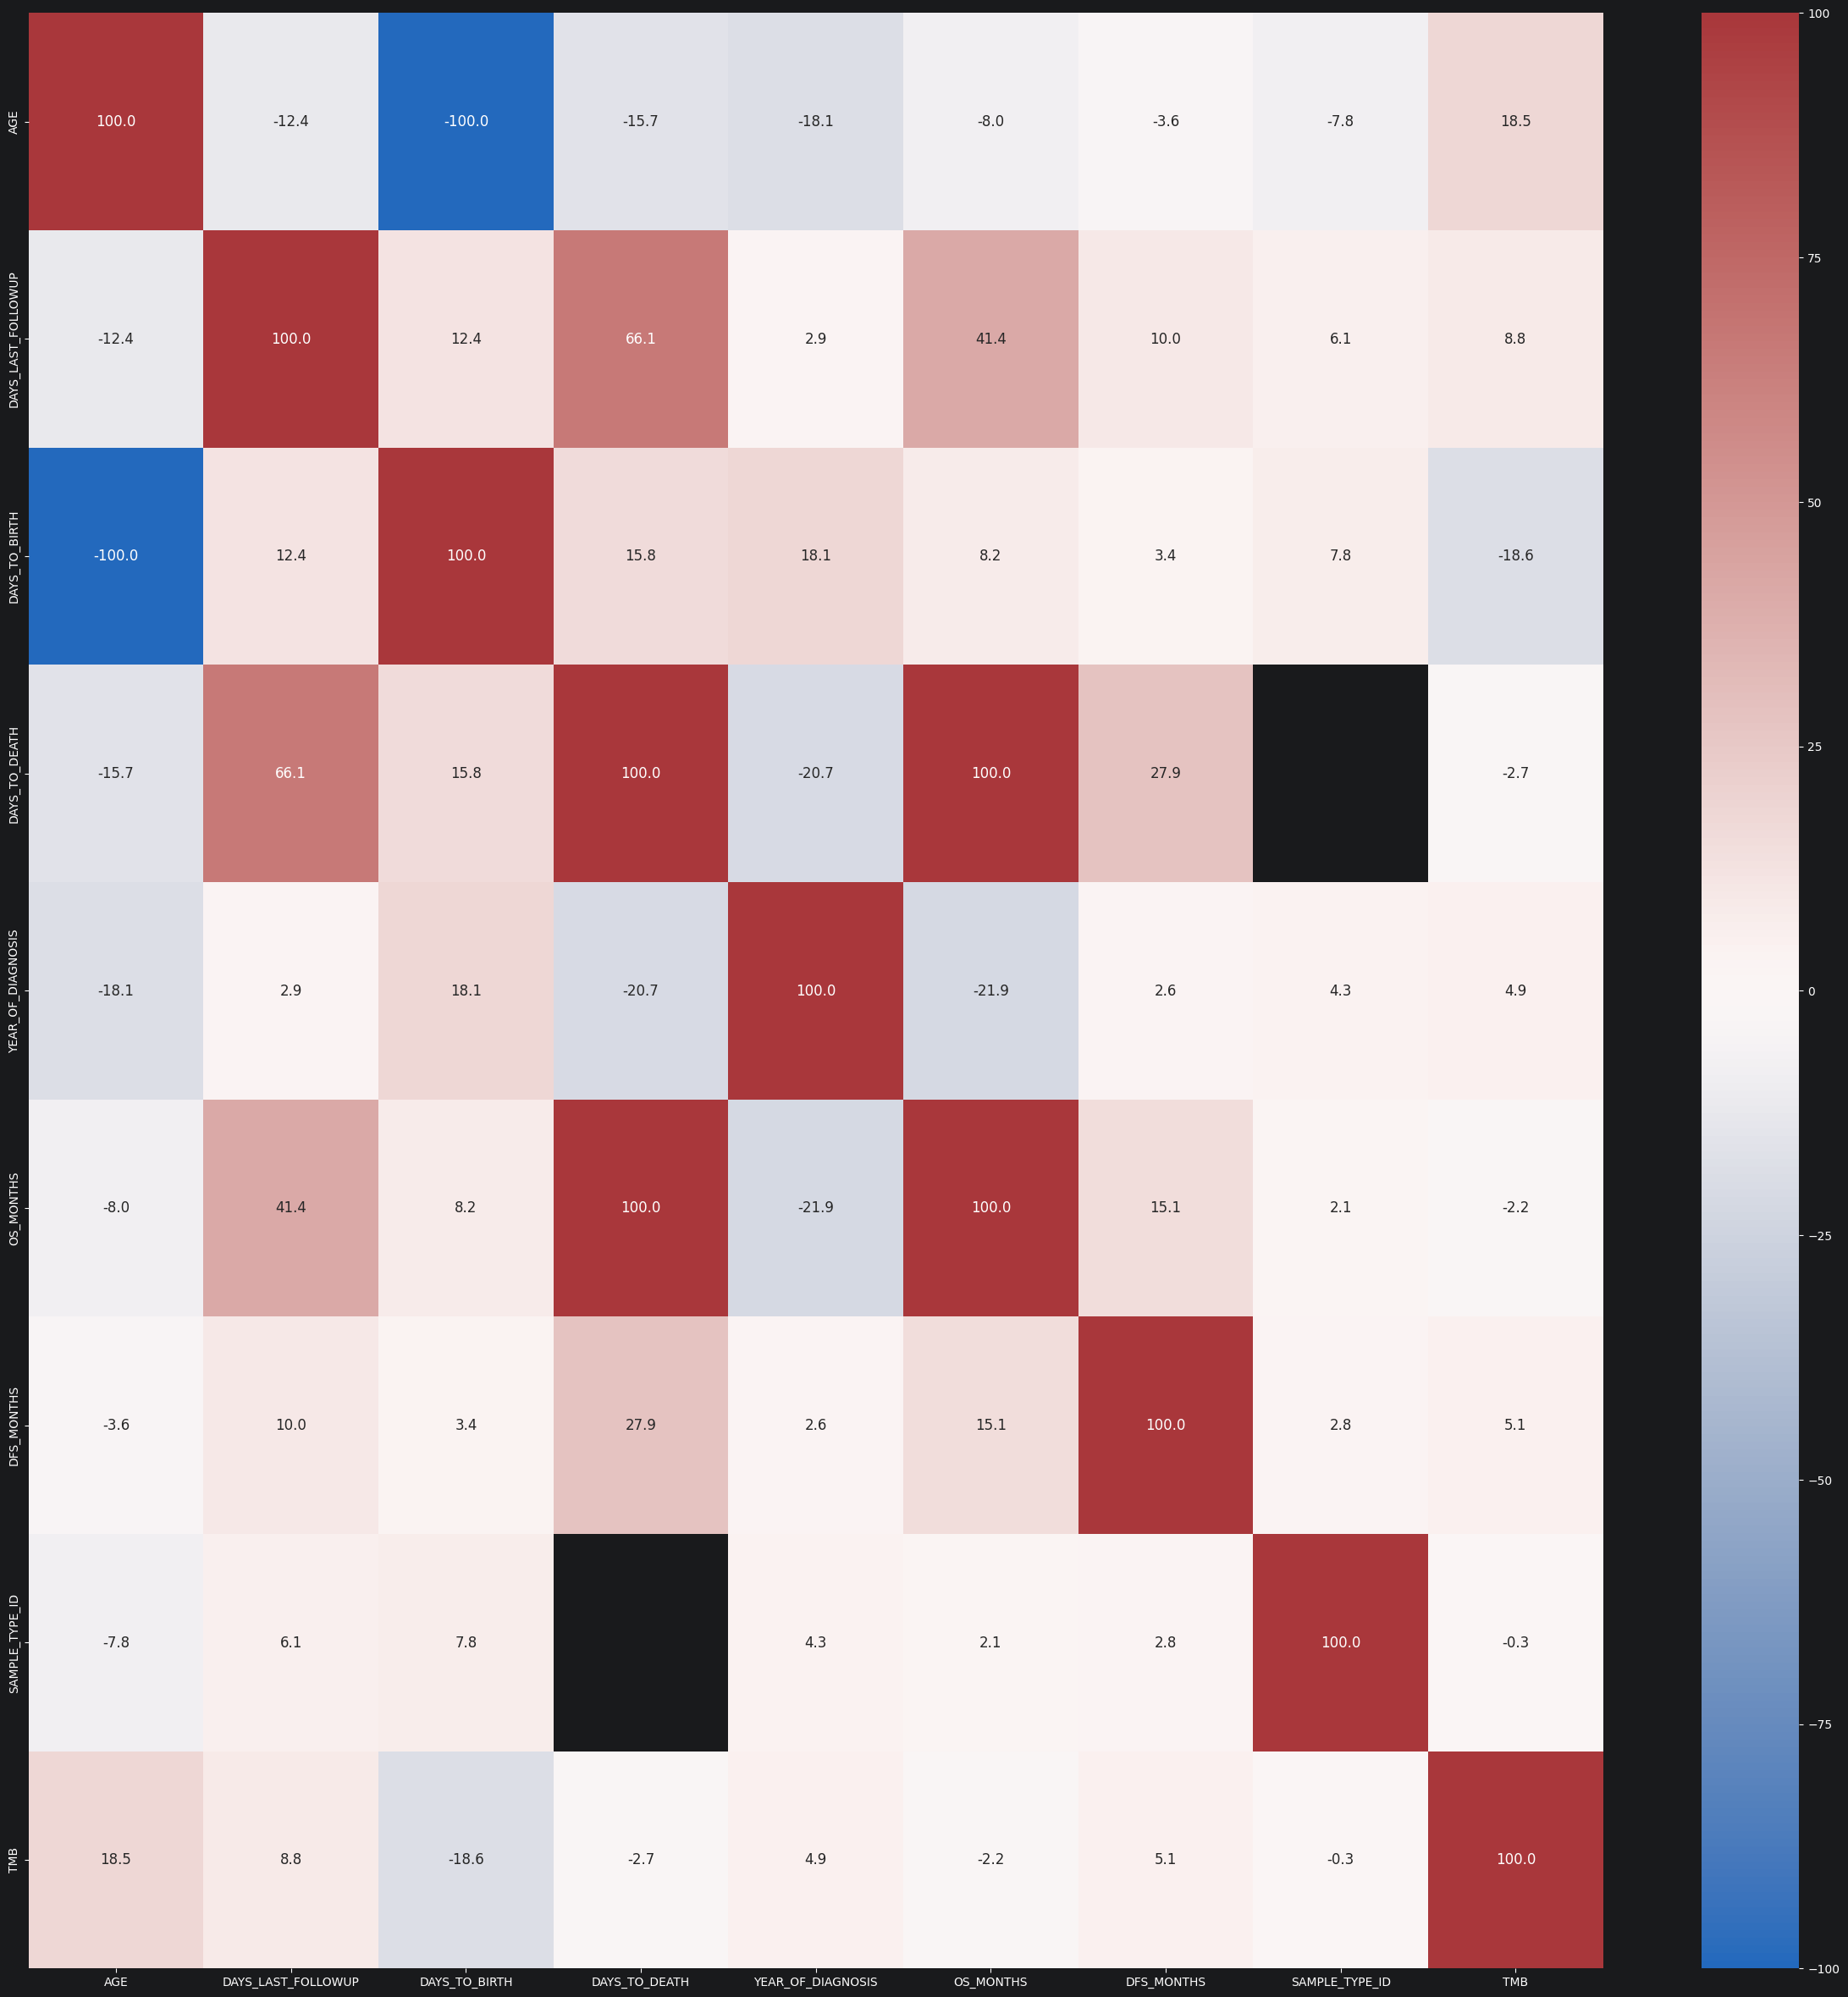

In [33]:
plt.figure(figsize=(30, 30))
sns.heatmap(
    df.corr(method="spearman", numeric_only=True) * 100,
    annot=True,
    fmt=".1f",
    cmap="vlag",
    vmin=-100,
    vmax=100,
    cbar=True,
    annot_kws={"size": 12},
)
# plt.savefig(
#     "../../../assets//EDA-charts/stad-clinical-numeric-corr-heatmap.png",
#     dpi=300,
#     bbox_inches="tight",
# )

In [30]:
df.to_parquet("../../../data/processed/stad_clinical_patient.parquet", engine="pyarrow")